In [45]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np

In [46]:
data = pd.read_csv("thyroid_dataset.csv")
data

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.00000,6.0000,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.00000,15.0000,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.00000,19.0000,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.00000,3.0000,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.00000,3.0000,5.0,116.0,4.0,o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0,n
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0,n
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0,n
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0,n


In [47]:
X = data.drop(columns=["Outlier_label"], axis=1)
y = data["Outlier_label"]
X.head()
y.info()
y

<class 'pandas.core.series.Series'>
RangeIndex: 6916 entries, 0 to 6915
Series name: Outlier_label
Non-Null Count  Dtype 
--------------  ----- 
6916 non-null   object
dtypes: object(1)
memory usage: 54.2+ KB


0       o
1       o
2       o
3       o
4       o
       ..
6911    n
6912    n
6913    n
6914    n
6915    n
Name: Outlier_label, Length: 6916, dtype: object

In [49]:

y= np.array(y)
for i in range(len(y)):
    if y[i]=="o":
        y[i]=1
    else:
        y[i]=0

y
        


array([1, 1, 1, ..., 0, 0, 0], shape=(6916,), dtype=object)

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-2.8000256 , -1.16360323],
       [-1.35756992, -0.95905031],
       [ 0.61449785, -2.64295808],
       ...,
       [ 0.97067278, -0.03570015],
       [-0.48569635,  1.00559244],
       [-0.31617833, -0.17796139]], shape=(6916, 2))

250


Text(0.5, 1.0, 'Original Anomalies')

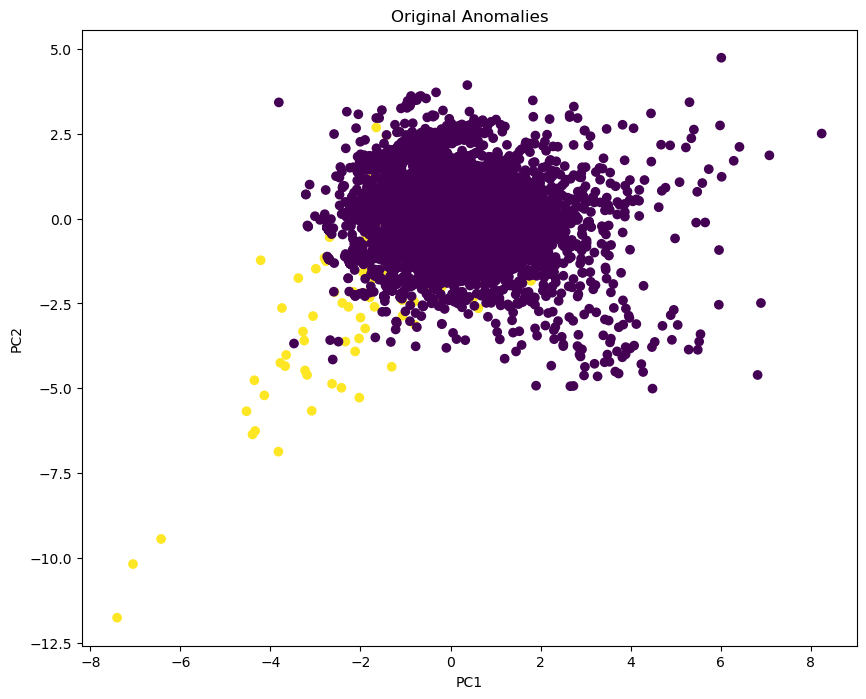

In [54]:
print(np.sum(y==1))
plt.figure(figsize=(10,8))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Original Anomalies")

In [60]:
clf = IsolationForest(n_estimators=201, contamination=0.036)
labels = clf.fit_predict(X_scaled)
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

249
6667


Text(0.5, 1.0, 'Isolation Forest Anomalies Prediction')

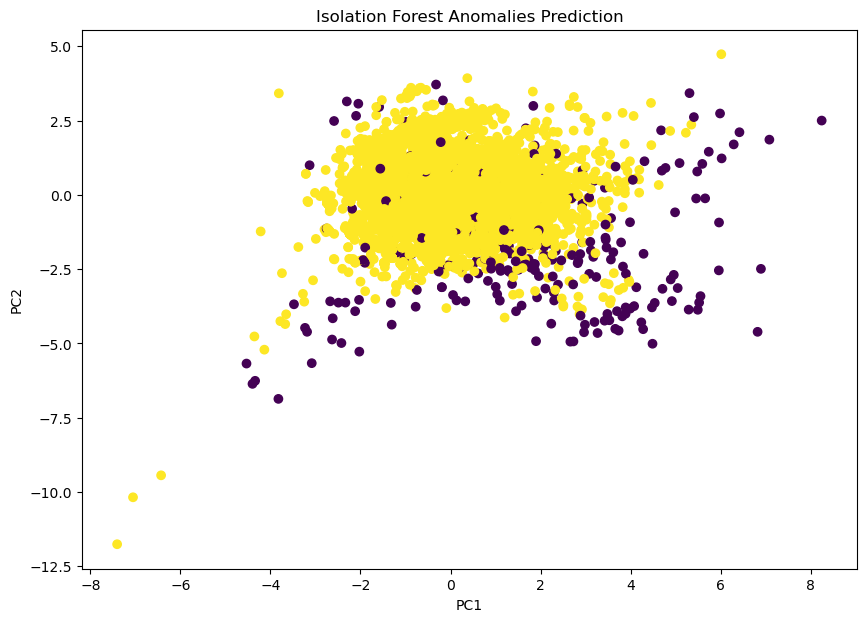

In [63]:
print("Anomalies Detected",np.sum(labels==-1))
print("",np.sum(labels==1))
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anomalies Prediction")
